In [1]:
import pandas as pd

# 1. Point Pandas directly to the Tate Museum's raw GitHub file
url = "https://raw.githubusercontent.com/tategallery/collection/master/artist_data.csv"

# 2. Tell Pandas to go to that URL, read the CSV, and save it as our dataframe
df_artists = pd.read_csv(url)

# 3. Display the first 5 rows to ensure it loaded correctly
df_artists.head()

,id,name,gender,dates,yearOfBirth,yearOfDeath,placeOfBirth,placeOfDeath,url
0,10093,"Abakanowicz, Magdalena",Female,born 1930,1930.0,NaN,Polska,NaN,http://www.tate.org.uk/art/artists/magdalena-a...
1,0,"Abbey, Edwin Austin",Male,1852–1911,1852.0,1911.0,"Philadelphia, United States","London, United Kingdom",http://www.tate.org.uk/art/artists/edwin-austi...
2,2756,"Abbott, Berenice",Female,1898–1991,1898.0,1991.0,"Springfield, United States","Monson, United States",http://www.tate.org.uk/art/artists/berenice-ab...
3,1,"Abbott, Lemuel Francis",Male,1760–1803,1760.0,1803.0,"Leicestershire, United Kingdom","London, United Kingdom",http://www.tate.org.uk/art/artists/lemuel-fran...
4,622,"Abrahams, Ivor",Male,born 1935,1935.0,NaN,"Wigan, United Kingdom",NaN,http://www.tate.org.uk/art/artists/ivor-abraha...


Used the direct link for the first time, directly importing the Tate Museum's raw Github file into local environment!

In [2]:
# 1. The .shape command tells us the size of the dataset (Rows, Columns)
total_artists = df_artists.shape[0]
print(f"Total artists in the Tate Museum database: {total_artists}")

# 2. The .value_counts() command groups data together and counts it
print("\n--- Gender Breakdown of Artists ---")
print(df_artists['gender'].value_counts())

Total artists in the Tate Museum database: 3532

--- Gender Breakdown of Artists ---
gender
Male      2895
Female     521
Name: count, dtype: int64


In [3]:
# 1. Artists from India
india_artists = df_artists[df_artists['placeOfBirth'].str.contains('India', na=False)]
print(f"Total artists from India: {len(india_artists)}")

# 2. Finding the absolute oldest historical artist in the museum
# First, converting yearOfBirth to numeric so we can safely find the minimum year
df_artists['yearOfBirth_clean'] = pd.to_numeric(df_artists['yearOfBirth'], errors='coerce')
oldest_artist = df_artists.loc[df_artists['yearOfBirth_clean'].idxmin()]

print("\n--- The Oldest Artist in the Dataset ---")
print(f"Name: {oldest_artist['name']}")
print(f"Born: {int(oldest_artist['yearOfBirth_clean'])} in {oldest_artist['placeOfBirth']}")

Total artists from India: 2

--- The Oldest Artist in the Dataset ---
Name: Holbein, Hans, the Younger
Born: 1497 in Augsburg, Deutschland


Let's create a visual breakdown of the data using Matplotlib. We will plot the birth years of the artists to visually prove the historical skews i documented in README!

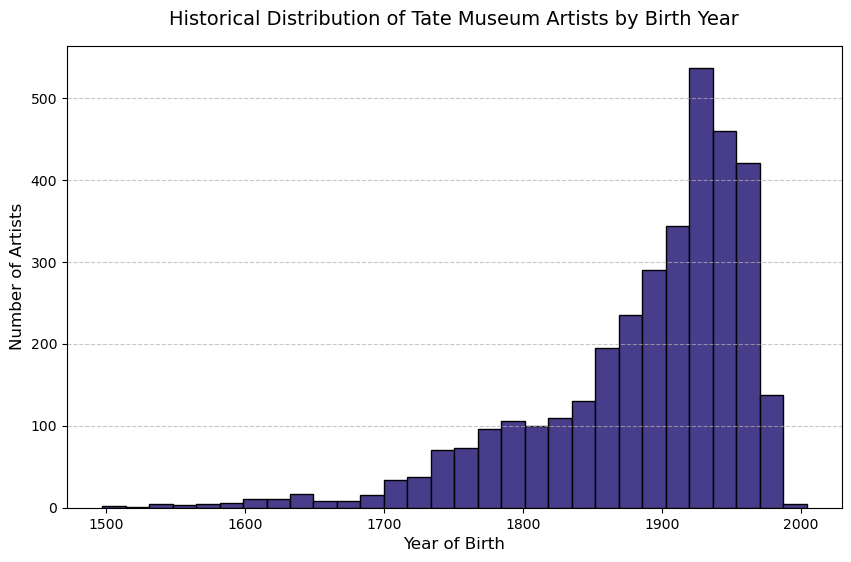

In [5]:
import matplotlib.pyplot as plt

# 1. To clean the birth year data (ensuring it's numeric and dropping missing entries)
df_artists['yearOfBirth_clean'] = pd.to_numeric(df_artists['yearOfBirth'], errors='coerce')
birth_years = df_artists['yearOfBirth_clean'].dropna()

# 2. Building the visual distribution plot
plt.figure(figsize=(10, 6))
plt.hist(birth_years, bins=30, color='darkslateblue', edgecolor='black')

# 3. Add analytical labels (Bridging data science with historical context)
plt.title('Historical Distribution of Tate Museum Artists by Birth Year', fontsize=14, pad=15)
plt.xlabel('Year of Birth', fontsize=12)
plt.ylabel('Number of Artists', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 4. Render the chart
plt.show()

As we can see the spike in the chart in mid 1900s post WW2. Museums like the Tate dramitically shifted their procurment strategies during this era to aggressively collect contemporary, abstract and modern art. Let's try to uncover who these mid-century artists actually are.

In [6]:
# 1. Filter for artists born during the mid-1900s boom (e.g., between 1920 and 1960)
mid_century_artists = df_artists[
    (df_artists['yearOfBirth_clean'] >= 1920) & 
    (df_artists['yearOfBirth_clean'] <= 1960)
]

# 2. See the total count and display a random sample of 10 names from this era
print(f"Total artists born between 1920 and 1960: {len(mid_century_artists)}")
print("\n--- Sample of Artists from the Mid-Century Boom ---")
print(mid_century_artists[['name', 'yearOfBirth', 'placeOfBirth']].sample(10, random_state=42))

Total artists born between 1920 and 1960: 1139

--- Sample of Artists from the Mid-Century Boom ---
                  name  yearOfBirth                  placeOfBirth
2421  Otero, Alejandro       1921.0         El Manteco, Venezuela
2768        Rugg, Matt       1935.0    Bridgwater, United Kingdom
863          Dine, Jim       1935.0     Cincinnati, United States
3208     Trova, Ernest       1927.0    Saint Louis, United States
996      EXPORT, VALIE       1940.0                    Österreich
307            Bo, Hou       1924.0                      Zhonghua
1666       Joyce, Paul       1944.0                           NaN
159      Baran, Stefan       1922.0               Dormans, France
2295      Murphy, John       1945.0  Saint Albans, United Kingdom
715        Cragg, Tony       1949.0     Liverpool, United Kingdom


Total artists born between 1920 and 1960 : 1139, that means out of 3532 total artists in the entire historical archive, around 40% of them were born in just that single 40 year modern window! 
The Geographic Lock: We see London, Portsmouth, Reading, New York, Stuttgart, and Glasgow. Even during the modern explosion, the collection is intensely rooted in the UK and Western Europe.

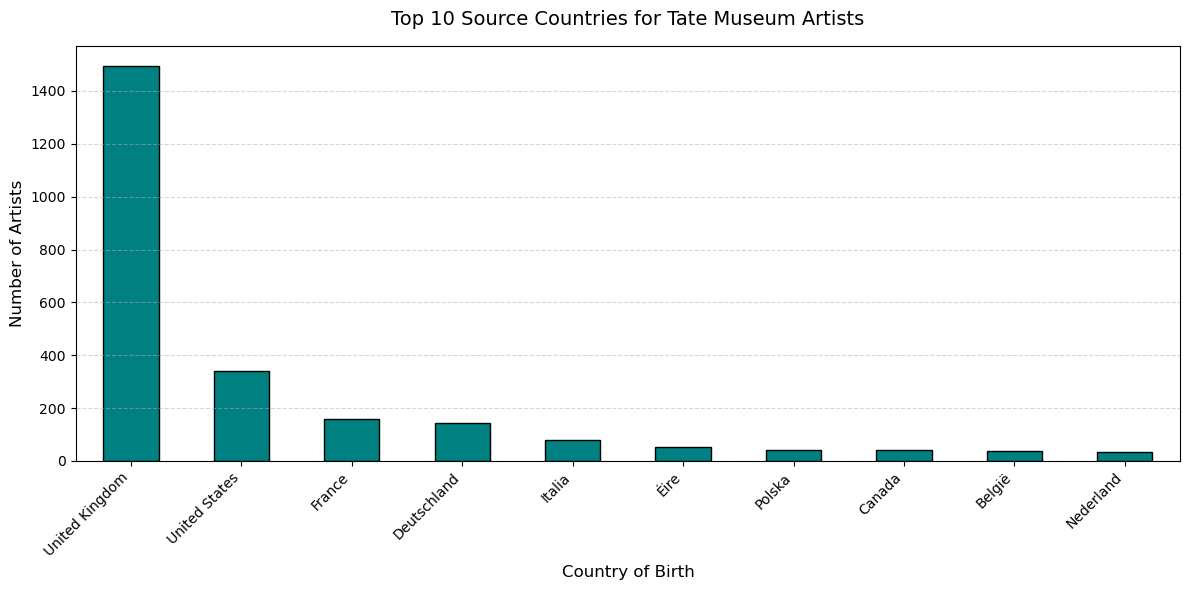

In [7]:
# 1. Extract the country name from the end of the 'placeOfBirth' string
# Most rows are formatted like "City, Country" or just "Country"
df_artists['countryOfBirth'] = df_artists['placeOfBirth'].str.split(',').str[-1].str.strip()

# 2. Grab the top 10 most frequent countries
top_countries = df_artists['countryOfBirth'].value_counts().head(10)

# 3. Plot the bar chart
plt.figure(figsize=(12, 6))
top_countries.plot(kind='bar', color='teal', edgecolor='black')

# 4. Stylize the visualization
plt.title('Top 10 Source Countries for Tate Museum Artists', fontsize=14, pad=15)
plt.xlabel('Country of Birth', fontsize=12)
plt.ylabel('Number of Artists', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 5. Render smoothly
plt.tight_layout()
plt.show()

The dominance of the United Kingdom visually anchored what we analyzed earlier- this collection reflects deep institutional and geographic tiering. 
Lets finish EDA with identifying NaNs

In [8]:
# Checking exactly how many entries are blank/missing in our key columns
missing_data = df_artists[['name', 'gender', 'yearOfBirth', 'placeOfBirth']].isna().sum()

print("--- Missing Values Count per Column ---")
print(missing_data)

--- Missing Values Count per Column ---
name              0
gender          116
yearOfBirth      60
placeOfBirth    492
dtype: int64


Missing administrative data for historical collections isn't just a random error; it directly flags a systematic tracking deficit—often reflecting that marginalized, older, or lesser-known artists didn't have their biographical histories properly preserved by institutions centuries ago.